# 07 · Trunk Fit & Dijkstra Branch Graph

**Goal:** turn the filtered point cloud into a structured branch graph
rooted at the trunk base. Implemented from scratch in `src/trunk.py` and
`src/branch_graph.py`.

Pipeline:
1. **`trunk.ransac_trunk_axis`** — RANSAC 3D line fit with a near-vertical
   prior; refit best inlier set by PCA; pick root as the inlier with the
   smallest signed projection on the axis (trunk base).
2. **`branch_graph.extract_branch_graph`** — kNN adjacency → Dijkstra
   shortest-path tree from the trunk root → spur pruning → collinear
   segment merging. The shortest-path tree IS the branching structure
   because real trees never rejoin themselves (no cycles in the canopy).


In [1]:
# Standard preamble.
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
np.random.seed(131)

import matplotlib.pyplot as plt
%matplotlib inline


## 0. Load the filtered cloud (output of notebook 06)

In [2]:
from src import sfm, trunk, branch_graph, viz

TREE_ID = "tree_5"

FILTERED_PLY = PROJECT_ROOT / "outputs" / "reconstructions" / f"{TREE_ID}_filtered.ply"
if not FILTERED_PLY.exists():
    raise FileNotFoundError(
        f"Filtered cloud not found at {FILTERED_PLY}. Run notebook 06 first."
    )

points, _ = sfm.load_ply(FILTERED_PLY)
print(f"Loaded {len(points)} filtered points from {FILTERED_PLY.name}")


Loaded 22213 filtered points from tree_5_filtered.ply


## 1. Fit the trunk axis (RANSAC + PCA refit)

`vertical_axis=2` assumes Z is up. If your COLMAP orientation ended up
with Y or X as the up axis, change accordingly — the most reliable way
to find which axis is up is to render the cloud and pick the axis along
which the trunk is longest.


In [3]:
fit = trunk.ransac_trunk_axis(
    points,
    num_iter=2000,
    inlier_thresh=0.05,
    vertical_prior=True,
    vertical_axis=2,         # change to 0 or 1 if your scene's up axis differs
    vertical_cos_min=0.7,    # require |dot(direction, up_axis)| >= 0.7
    rng=np.random.default_rng(131),
)
n_inliers = int(fit.inlier_mask.sum())
print(f"Trunk inliers: {n_inliers} / {len(points)}  ({100*n_inliers/len(points):.1f}%)")
print(f"Mean inlier perp distance: {fit.inlier_distance_mean*100:.2f} cm")
print(f"Trunk root: {fit.root}")
print(f"Direction:  {fit.direction}")
print(f"Trunk height (extent of inliers along axis): {trunk.trunk_height(fit, points):.2f}")


Trunk inliers: 814 / 22213  (3.7%)
Mean inlier perp distance: 2.92 cm
Trunk root: [-1.26329804  2.65497292  3.05217406]
Direction:  [ 0.13071368 -0.63427286  0.76197892]
Trunk height (extent of inliers along axis): 9.65


## 2. Extract the branch graph

`extract_branch_graph` glues together kNN graph construction, Dijkstra
from the trunk root, spur pruning, and collinear segment merging. The
result is a tree-shaped graph where each edge corresponds to a branch
segment.


In [4]:
graph = branch_graph.extract_branch_graph(
    points,
    trunk_root_xyz=fit.root,
    k=12,
    max_edge_length=2.0,         # tune to your scene scale (metres if COLMAP is metric)
    min_spur_length=0.30,
    collinear_tolerance_deg=12.0,
)
print(f"Skeleton: {len(graph.nodes)} nodes, {len(graph.edges)} edges after pruning + merging")


Skeleton: 5007 nodes, 5006 edges after pruning + merging


## 3. Visualise — branch graph overlaid on the trunk axis

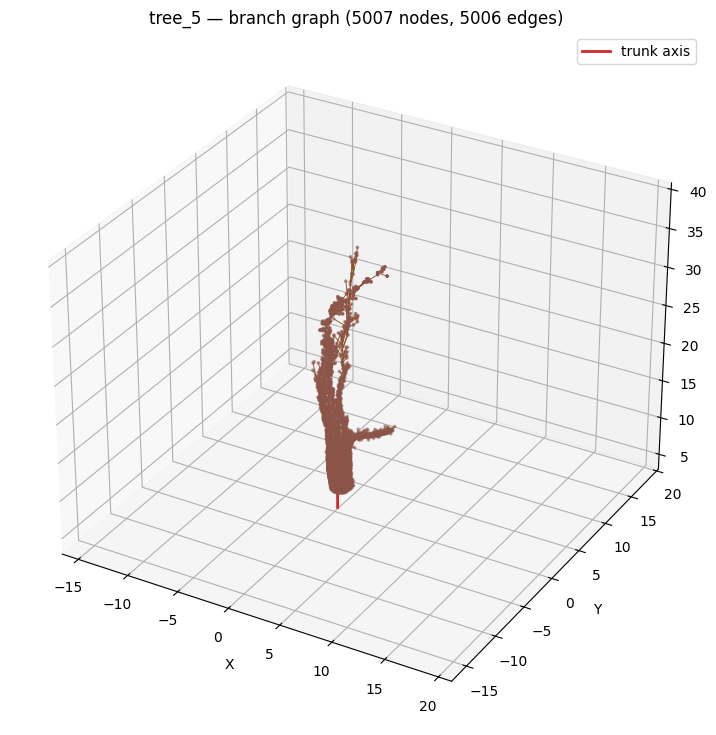

In [5]:
fig = viz.plot_branch_graph(
    graph.nodes, graph.edges,
    trunk_axis=(fit.root, fit.direction),
    title=f"{TREE_ID} — branch graph "
          f"({len(graph.nodes)} nodes, {len(graph.edges)} edges)",
)
viz.save_fig(fig, f"07_{TREE_ID}_branch_graph.png")
plt.show()


## 4. Persist the graph for evaluation (notebook 08)

In [6]:
out = PROJECT_ROOT / "outputs" / "reconstructions" / f"{TREE_ID}_graph.npz"
np.savez(
    out,
    nodes=graph.nodes,
    edges=np.array(graph.edges, dtype=np.int64),
    trunk_root=fit.root,
    trunk_direction=fit.direction,
    parents=np.array(list(graph.parent_of.items()), dtype=np.int64),
    distances=graph.distances,
)
print(f"Saved branch graph → {out}")


Saved branch graph → /Users/colevanhersett/Developer/uni/CS_131/final_proj/outputs/reconstructions/tree_5_graph.npz


In [ ]:
# ── Interactive 3D branch graph (Plotly) ─────────────────────────────────────
# Rotate / zoom with the mouse to find the best viewing angle, then click the
# camera icon (top-right of the plot) to download a PNG at that exact view.
# Also writes a standalone interactive .html you can open in any browser — a
# handy live artifact for Demo Day. (No new deps: plotly is already installed.)
import plotly.graph_objects as go

# Align the recovered trunk to plot-vertical (+Z), matching the static figure.
R       = viz.rotation_aligning(fit.direction, np.array([0.0, 0.0, 1.0]))
nodes_v = (R @ (graph.nodes - fit.root).T).T + fit.root
dir_v   = R @ fit.direction

# All branch edges as ONE line trace (None between segments = one fast trace).
ex, ey, ez = [], [], []
for i, j in graph.edges:
    ex += [nodes_v[i, 0], nodes_v[j, 0], None]
    ey += [nodes_v[i, 1], nodes_v[j, 1], None]
    ez += [nodes_v[i, 2], nodes_v[j, 2], None]

ts    = np.linspace(-2, 2, 50)
trunk = fit.root[None, :] + ts[:, None] * dir_v[None, :]

fig3d = go.Figure([
    go.Scatter3d(x=ex, y=ey, z=ez, mode="lines",
                 line=dict(color="saddlebrown", width=2),
                 name="branches", hoverinfo="skip"),
    go.Scatter3d(x=nodes_v[:, 0], y=nodes_v[:, 1], z=nodes_v[:, 2],
                 mode="markers", marker=dict(size=1.6, color="sienna"),
                 name="nodes", hoverinfo="skip"),
    go.Scatter3d(x=trunk[:, 0], y=trunk[:, 1], z=trunk[:, 2],
                 mode="lines", line=dict(color="red", width=6),
                 name="trunk axis"),
])
fig3d.update_layout(
    title=f"{TREE_ID} — branch graph (interactive)",
    scene=dict(aspectmode="data",  # equal aspect → geometry not distorted
               xaxis_title="X", yaxis_title="Y", zaxis_title="Z"),
    margin=dict(l=0, r=0, t=40, b=0), height=800,
)

_html = PROJECT_ROOT / "outputs" / "figures" / f"07_{TREE_ID}_branch_graph_interactive.html"
fig3d.write_html(str(_html))
print(f"Interactive HTML → {_html}")
fig3d.show()